# "That's What She Said" — A Data Analysis of The Office

Author: Alaz Peker-Röhrig 

Date: March 2026  

Tools: Python, Pandas, Matplotlib, Seaborn

## Overview
Michael Scott's favourite joke — *"That's what she said"* — is one of the most iconic 
running gags in TV history. This analysis explores how the joke evolved across all 9 
seasons of The Office (US), who said it, when it peaked, and what happened after 
Michael left.

## Dataset
- Office Scripts: 54,626 lines of dialogue across 201 episodes
- Source: Kaggle — The Office (US) Complete Dialogue/Transcript by Nasir Khalid (Updated 5 years ago) &
          Kaggle —    The Office Episodes Data - Episodes and ratings for NBC's The Office by Bill Cruise (Updated 4 years ago)

## Key Questions
1. How did TWSS frequency change across seasons?
2. Which characters used it and how often?
3. How long did audiences wait between occurrences?
4. Is there a relationship between TWSS and viewership?

## 1. Setup & Data Loading

We begin by importing the necessary libraries and loading two datasets:
- `office_lines.csv` — full dialogue transcript for all 9 seasons
- `office_episodes.csv` — episode-level metadata including viewership numbers

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib import rcParams
import os

# Create charts folder for saving outputs
os.makedirs('charts', exist_ok=True)

# Global style
rcParams['font.family'] = 'Georgia'
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['axes.titlepad'] = 15
rcParams['axes.titlesize'] = 15
rcParams['axes.titleweight'] = 'bold'
rcParams['axes.labelsize'] = 11
rcParams['axes.labelcolor'] = '#444444'
rcParams['xtick.color'] = '#666666'
rcParams['ytick.color'] = '#666666'
rcParams['figure.facecolor'] = '#FFFDF8'
rcParams['axes.facecolor'] = '#FFFDF8'
rcParams['axes.edgecolor'] = '#CCCCCC'

# Warm Office colour palette
ORANGE      = '#D95F02'   # Michael — dominant
BROWN       = '#7B3F00'   # Dwight
BLUE        = '#4A90D9'   # Jim
PURPLE      = '#8E44AD'   # Jan
PINK        = '#E91E8C'   # Holly
GREEN       = '#27AE60'   # Pam
YELLOW      = '#F4A623'   # Creed
TEAL        = "#66EBF0"   # David
GREY        = '#95A5A6'   # Deposition Reporter
MUTED       = '#C8D6E0'   # background/inactive bars
CREAM       = '#FFFDF8'   # background

character_colors = {
    'Michael': ORANGE, 'Dwight': BROWN, 'Jim': BLUE,
    'Jan': PURPLE, 'Holly': PINK, 'Pam': GREEN,
    'Creed': YELLOW, 'David': TEAL, 'Deposition Reporter': GREY
}

print("Let's analyze the Office's TWSS lines!")


Let's analyze the Office's TWSS lines!


In [2]:
# Load datasets 
scripts = pd.read_csv('office_lines.csv')
episodes = pd.read_csv('office_episodes.csv')

# Drop empty column from scripts
scripts = scripts.drop(columns=['Unnamed: 6'])

# Preview
print("Scripts shape:", scripts.shape)
print("Episodes shape:", episodes.shape)
print("\nScripts preview:")
print(scripts.head())

Scripts shape: (54626, 6)
Episodes shape: (201, 9)

Scripts preview:
   season  episode  title  scene  speaker  \
0       1        1  Pilot      1  Michael   
1       1        1  Pilot      1      Jim   
2       1        1  Pilot      1  Michael   
3       1        1  Pilot      1      Jim   
4       1        1  Pilot      1  Michael   

                                                line  
0  All right Jim. Your quarterlies look very good...  
1         Oh, I told you. I couldn't close it. So...  
2  So you've come to the master for guidance? Is ...  
3         Actually, you called me in here, but yeah.  
4    All right. Well, let me show you how it's done.  


The scripts dataset contains **54,626 lines** of dialogue across **201 episodes**. 
Each row represents a single line, with columns for season, episode, title, scene, 
speaker, and the line itself.

## 2. Data Cleaning & Filtering

We drop an empty column from the scripts data, then filter all dialogue for any 
variation of "that's what she said" using a case-insensitive search. This returns 
our core analysis dataset of **34 confirmed instances** across the show's run.

In [3]:
# Filter for all TWSS instances
twss = scripts[scripts['line'].str.contains("that's what she said", case=False, na=False)]

# Create clean dataframe
twss_clean = twss[['season', 'episode', 'speaker', 'line']].reset_index(drop=True)

# Preview
print("Total TWSS count:", len(twss_clean))
print(twss_clean.to_string())

Total TWSS count: 34
    season  episode              speaker                                                                                                                                                                                                                                                                                                                                       line
0        2        2              Michael                                                                                                                                                                                                                                                                                                                 That's what she said. Pam?
1        2        2                  Jim                                                                                                                                                                                                   

## 3. Analysis & Visualisations

### 3.1 Frequency by Season
How often did the joke appear each season? We count instances per season,
filling in zeros for seasons with no occurrences (S1 and S8).

In [4]:
# Check season distribution of TWSS lines
print(twss_clean.groupby('season').size())

season
2     7
3     6
4    10
5     4
6     1
7     4
9     2
dtype: int64


In [5]:
# Verify Season 1 is not missing data and check for "she said" variations
season1 = scripts[scripts['season'] == 1]
print("Total Season 1 lines:", len(season1))
print("\nSearching for 'she said' variations in Season 1:")
print(season1[season1['line'].str.contains("she said", case=False, na=False)][['episode', 'speaker', 'line']])

Total Season 1 lines: 1487

Searching for 'she said' variations in Season 1:
Empty DataFrame
Columns: [episode, speaker, line]
Index: []


#### 💡 Why Does Season 1 Have Zero TWSS Instances?

The absence of "That's What She Said" in Season 1 is not a data gap — it is 
a deliberate creative choice that reflects the show's origins.

The US Office (2005) was directly adapted from Ricky Gervais and Stephen 
Merchant's UK original (2001). Season 1 closely mirrors the UK version in 
tone, structure, and even specific scenes. David Brent — the UK equivalent 
of Michael Scott — never used the TWSS joke. The humour in the UK version 
was more cringe-based and awkward rather than improvisational and silly.

From Season 2 onwards, the writers began diverging from the UK source 
material and developing Michael Scott as a distinctly American character — 
more childlike, more improvisational, and more desperate for approval. 
The TWSS joke perfectly encapsulates this shift: it is juvenile, reflexive, 
and driven by a need to get a laugh at any cost.

> *In this sense, the first appearance of "That's What She Said" in S2E2 
> marks the moment Michael Scott truly became his own character.*

### 3.2 Character Breakdown
While TWSS is Michael's signature joke, other characters occasionally use it 
too. Here we look at who said it and how many times.

In [6]:
# Count by speaker
twss_by_speaker = twss_clean.groupby('speaker').size().reset_index(name='count')
twss_by_speaker = twss_by_speaker.sort_values('count', ascending=False)
print(twss_by_speaker)

               speaker  count
7              Michael     23
3               Dwight      3
6                  Jim      2
0                Creed      1
1                David      1
4                Holly      1
2  Deposition Reporter      1
5                  Jan      1
8                  Pam      1


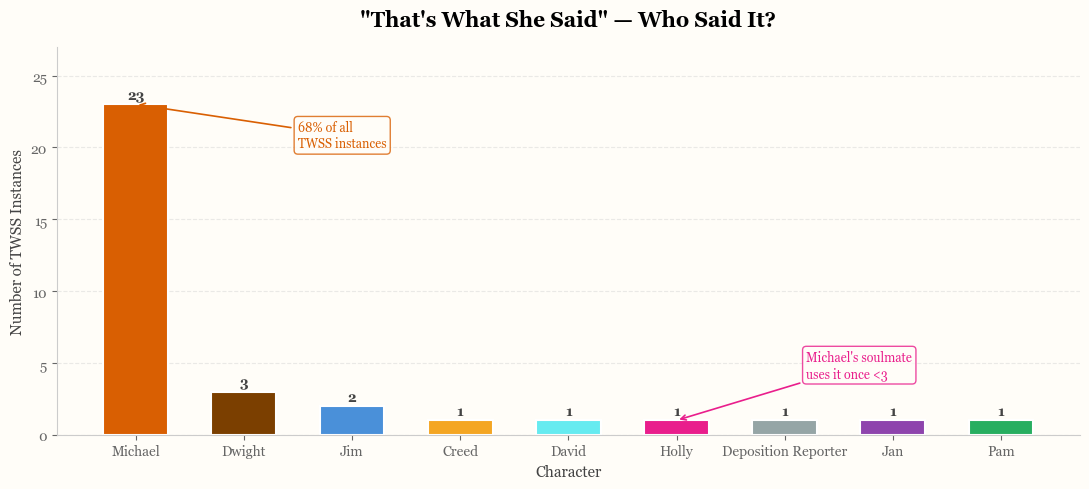

Chart 1 saved ✅


In [7]:
# Character breakdown bar chart (Chart 1)
fig, ax = plt.subplots(figsize=(11, 5), facecolor=CREAM)
ax.set_facecolor(CREAM)

colors = [character_colors.get(s, MUTED) for s in twss_by_speaker['speaker']]
bars = ax.bar(twss_by_speaker['speaker'], twss_by_speaker['count'],
              color=colors, edgecolor='white', linewidth=1.5, width=0.6)

# Count labels on bars
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            int(bar.get_height()), ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#444444')

# Annotation for Michael's dominance
ax.annotate("68% of all\nTWSS instances",
            xy=(0, 23), xytext=(1.5, 20),
            fontsize=9, color=ORANGE,
            arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor=CREAM, edgecolor=ORANGE, alpha=0.8))

# Annotation for Holly
holly_idx = list(twss_by_speaker['speaker']).index('Holly')
ax.annotate("Michael's soulmate\nuses it once <3",
            xy=(holly_idx, 1), xytext=(holly_idx + 1.2, 4),
            fontsize=9, color=PINK,
            arrowprops=dict(arrowstyle='->', color=PINK, lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor=CREAM, edgecolor=PINK, alpha=0.8))

# Axes formatting
ax.set_xlabel("Character")
ax.set_ylabel("Number of TWSS Instances")
ax.set_title('"That\'s What She Said" — Who Said It?')
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#CCCCCC')
ax.set_axisbelow(True)
ax.set_ylim(0, 27)

plt.tight_layout()
plt.savefig('charts/01_character_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved ✅")

### 3.3 Season × Character Breakdown
Combining season and speaker shows not just *when* the joke peaked, 
but *who* was carrying it each season.

In [8]:
# TWSS by season AND speaker
twss_by_season_speaker = twss_clean.groupby(['season', 'speaker']).size().reset_index(name='count')

# Pivot so each speaker becomes a column
twss_pivot = twss_by_season_speaker.pivot(index='season', columns='speaker', values='count').fillna(0)

# Reindex to include all 9 seasons
twss_pivot = twss_pivot.reindex(range(1, 10), fill_value=0)

print(twss_pivot)

speaker  Creed  David  Deposition Reporter  Dwight  Holly  Jan  Jim  Michael  \
season                                                                         
1          0.0    0.0                  0.0     0.0    0.0  0.0  0.0      0.0   
2          0.0    0.0                  0.0     1.0    0.0  0.0  1.0      5.0   
3          0.0    0.0                  0.0     1.0    0.0  1.0  0.0      4.0   
4          0.0    0.0                  1.0     0.0    0.0  0.0  1.0      8.0   
5          0.0    0.0                  0.0     1.0    0.0  0.0  0.0      2.0   
6          0.0    0.0                  0.0     0.0    0.0  0.0  0.0      1.0   
7          0.0    1.0                  0.0     0.0    1.0  0.0  0.0      2.0   
8          0.0    0.0                  0.0     0.0    0.0  0.0  0.0      0.0   
9          1.0    0.0                  0.0     0.0    0.0  0.0  0.0      1.0   

speaker  Pam  
season        
1        0.0  
2        0.0  
3        0.0  
4        0.0  
5        1.0  
6        0.0  

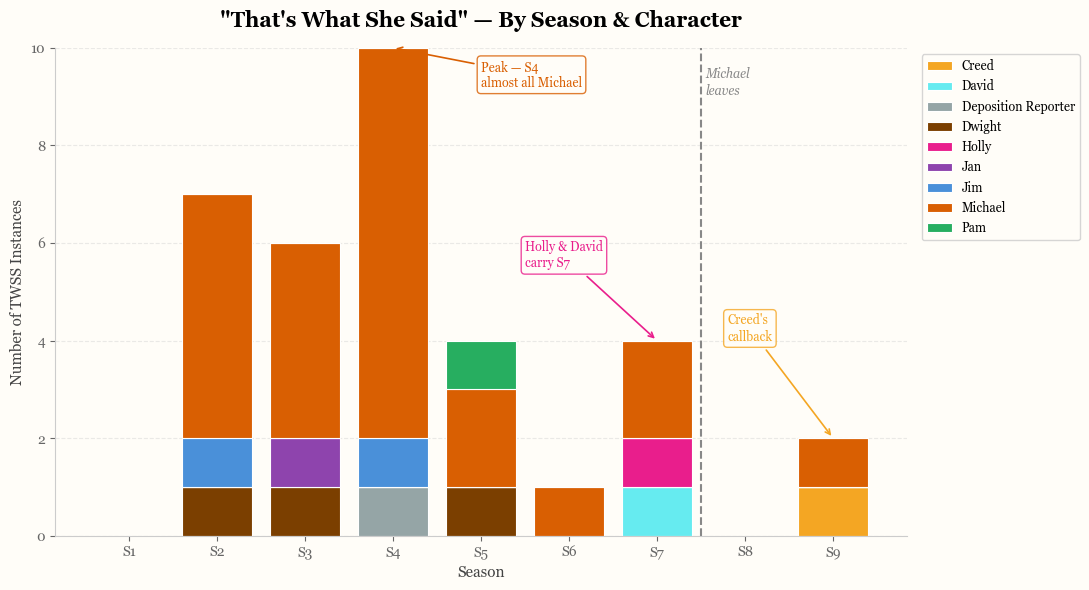

Chart 2 saved ✅


In [9]:
# Season x Character stacked bar chart (Chart 2)
fig, ax = plt.subplots(figsize=(11, 6), facecolor=CREAM)
ax.set_facecolor(CREAM)

bottom = pd.Series([0.0] * 9, index=range(1, 10))
for character in twss_pivot.columns:
    color = character_colors.get(character, MUTED)
    ax.bar(twss_pivot.index, twss_pivot[character], bottom=bottom,
           label=character, color=color, edgecolor='white', linewidth=0.8)
    bottom += twss_pivot[character]

# Michael departure line
ax.axvline(x=7.5, color='#888888', linestyle='--', linewidth=1.5, zorder=2)
ax.text(7.55, 9.6, "Michael\nleaves", fontsize=9, color='#888888',
        va='top', style='italic')

# Annotations
ax.annotate("Peak — S4\nalmost all Michael",
            xy=(4, 10), xytext=(5.0, 9.2),
            fontsize=9, color=ORANGE,
            arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor=CREAM, edgecolor=ORANGE, alpha=0.8))

ax.annotate("Holly & David\ncarry S7",
            xy=(7, 4), xytext=(5.5, 5.5),
            fontsize=9, color=PINK,
            arrowprops=dict(arrowstyle='->', color=PINK, lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor=CREAM, edgecolor=PINK, alpha=0.8))

ax.annotate("Creed's\ncallback",
            xy=(9, 2), xytext=(7.8, 4),
            fontsize=9, color=YELLOW,
            arrowprops=dict(arrowstyle='->', color=YELLOW, lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor=CREAM, edgecolor=YELLOW, alpha=0.8))

# Axes formatting
ax.set_xticks(range(1, 10))
ax.set_xticklabels([f'S{i}' for i in range(1, 10)])
ax.set_xlabel("Season")
ax.set_ylabel("Number of TWSS Instances")
ax.set_title('"That\'s What She Said" — By Season & Character')
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#CCCCCC')
ax.set_axisbelow(True)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('charts/02_season_character.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved ✅")

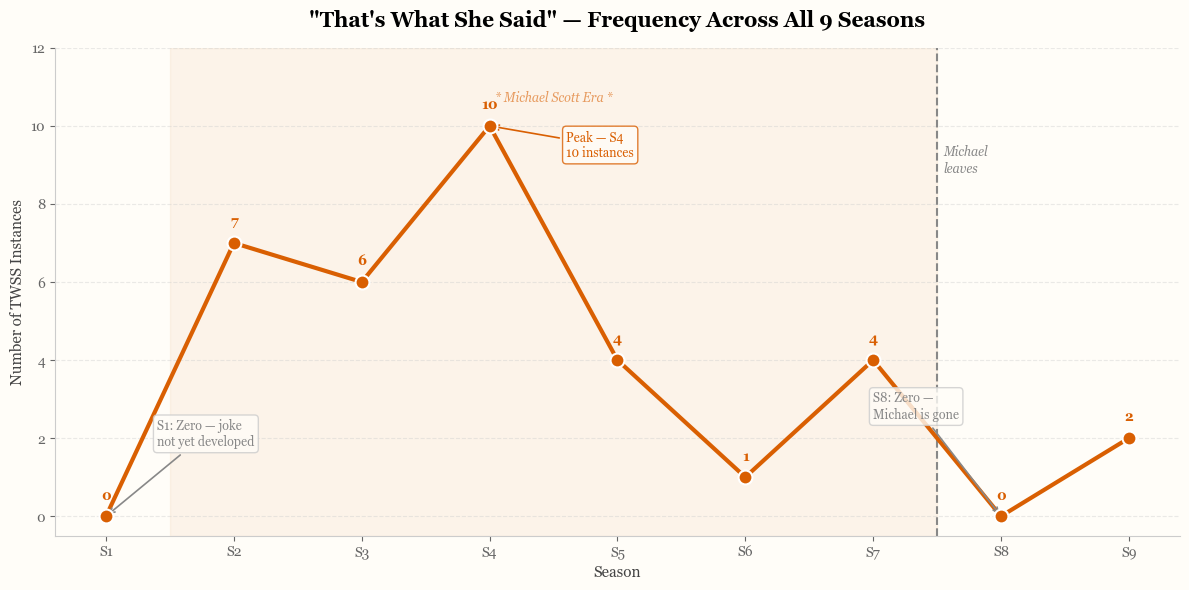

Chart 3 saved ✅


In [10]:
# Data prep
all_seasons = pd.DataFrame({'season': range(1, 10)})
twss_by_season = twss_clean.groupby('season').size().reset_index(name='count')
twss_by_season = all_seasons.merge(twss_by_season, on='season', how='left').fillna(0)
twss_by_season['count'] = twss_by_season['count'].astype(int)

# Season frequency line chart (Chart 3)
fig, ax = plt.subplots(figsize=(12, 6), facecolor=CREAM)
ax.set_facecolor(CREAM)

ax.axvspan(1.5, 7.5, alpha=0.06, color=ORANGE, zorder=0)
ax.plot(twss_by_season['season'], twss_by_season['count'],
        color=ORANGE, linewidth=3, zorder=3)
ax.scatter(twss_by_season['season'], twss_by_season['count'],
           color=ORANGE, s=100, zorder=4, edgecolors='white', linewidths=1.5)

for _, row in twss_by_season.iterrows():
    ax.annotate(int(row['count']),
                (row['season'], row['count']),
                textcoords="offset points", xytext=(0, 12),
                ha='center', fontsize=10, color=ORANGE, fontweight='bold')

ax.axvline(x=7.5, color='#888888', linestyle='--', linewidth=1.5, zorder=2)
ax.text(7.55, 9.5, "Michael\nleaves", fontsize=9, color='#888888',
        va='top', style='italic')

ax.annotate("Peak — S4\n10 instances",
            xy=(4, 10), xytext=(4.6, 9.2),
            fontsize=9, color=ORANGE,
            arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor=CREAM, edgecolor=ORANGE, alpha=0.8))

ax.annotate("S1: Zero — joke\nnot yet developed",
            xy=(1, 0), xytext=(1.4, 1.8),
            fontsize=9, color='#888888',
            arrowprops=dict(arrowstyle='->', color='#888888', lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor=CREAM, edgecolor='#CCCCCC', alpha=0.8))

ax.annotate("S8: Zero —\nMichael is gone",
            xy=(8, 0), xytext=(7.0, 2.5),
            fontsize=9, color='#888888',
            arrowprops=dict(arrowstyle='->', color='#888888', lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor=CREAM, edgecolor='#CCCCCC', alpha=0.8))

ax.text(4.5, 10.6, "* Michael Scott Era *",
        ha='center', fontsize=9, color=ORANGE, alpha=0.6, style='italic')

ax.set_xticks(range(1, 10))
ax.set_xticklabels([f'S{i}' for i in range(1, 10)])
ax.set_xlabel("Season")
ax.set_ylabel("Number of TWSS Instances")
ax.set_title('"That\'s What She Said" — Frequency Across All 9 Seasons')
ax.set_ylim(-0.5, 12)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#CCCCCC')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('charts/03_season_frequency.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved ✅")

### 3.4 Gap Analysis — How Long Did We Wait?
Between each TWSS instance, how many episodes passed? This reveals the 
rhythm of the joke — frequent during peak seasons, increasingly rare toward the end.

In [11]:
# Merge to get real overall episode numbers for gap analysis
twss_merged = twss_clean.merge(
    episodes[['season', 'episode_num_in_season', 'episode_num_overall']],
    left_on=['season', 'episode'],
    right_on=['season', 'episode_num_in_season'],
    how='left'
)

# Sort and calculate gaps 
twss_merged = twss_merged.sort_values('episode_num_overall').reset_index(drop=True)
twss_merged['gap'] = twss_merged['episode_num_overall'].diff().fillna(0).astype(int)

print(twss_merged[['season', 'episode', 'speaker', 'episode_num_overall', 'gap']].to_string())

    season  episode              speaker  episode_num_overall  gap
0        2        2              Michael                    8    0
1        2        2                  Jim                    8    0
2        2        2              Michael                    8    0
3        2       10              Michael                   16    8
4        2       12               Dwight                   18    2
5        2       17              Michael                   23    5
6        2       21              Michael                   27    4
7        3        1              Michael                   29    2
8        3       10              Michael                   38    9
9        3       13               Dwight                   41    3
10       3       18              Michael                   46    5
11       3       18                  Jan                   46    0
12       3       21              Michael                   49    3
13       4        3              Michael                   56 

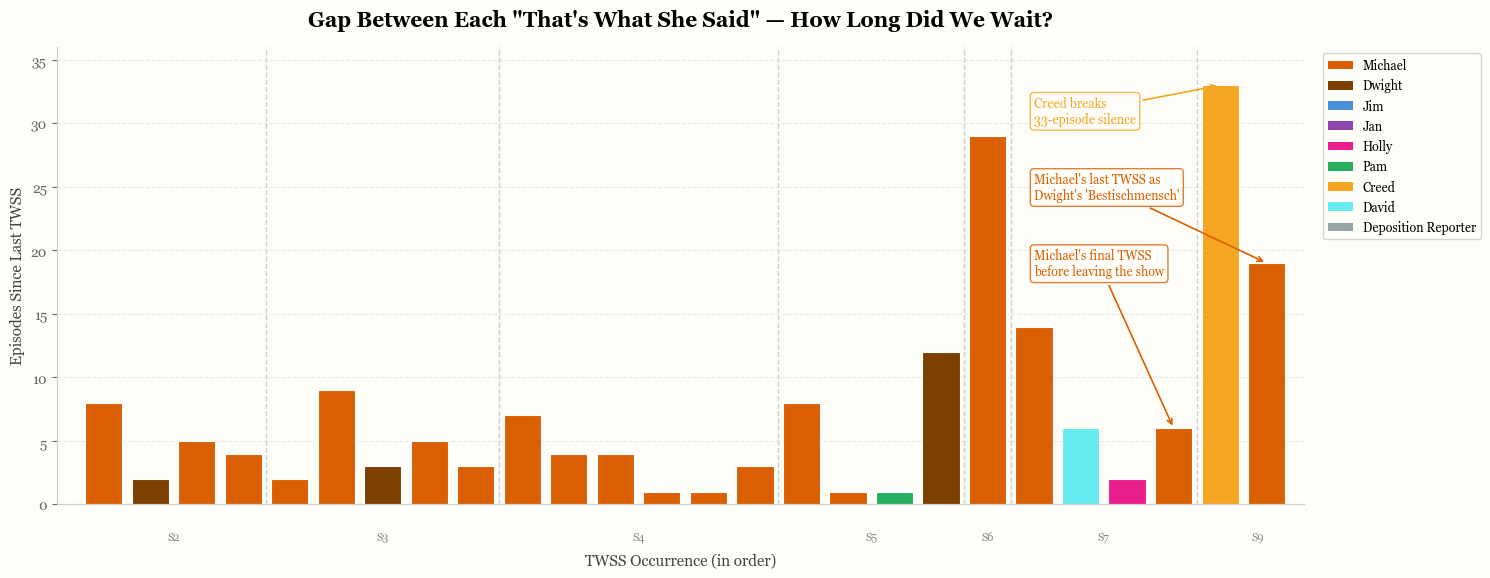

Chart 4 saved ✅


In [12]:
# Data prep for gap timeline chart
twss_unique_eps = twss_merged.drop_duplicates(subset='episode_num_overall').reset_index(drop=True)
twss_unique_eps['gap'] = twss_unique_eps['episode_num_overall'].diff().fillna(0).astype(int)

# Gap timeline chart (Chart 4)
fig, ax = plt.subplots(figsize=(15, 6), facecolor=CREAM)
ax.set_facecolor(CREAM)

colors = [character_colors.get(s, MUTED) for s in twss_unique_eps['speaker']]
ax.bar(range(len(twss_unique_eps)), twss_unique_eps['gap'],
       color=colors, edgecolor='white', linewidth=0.8)

# Season markers (S1 and S8 omitted — no TWSS)
season_boundaries = [
    (2,  -0.5,   2.5),
    (3,   4.5,   7.0),
    (4,   9.5,  12.5),
    (5,  15.5,  17.5),
    (6,  19.5,  20.0),
    (7,  20.5,  22.5),
    (9,  24.5,  25.8),
]

for season, line_x, label_x in season_boundaries:
    ax.axvline(x=line_x, color='#CCCCCC', linestyle='--', linewidth=1)
    ax.text(label_x, -2.8, f'S{season}',
            fontsize=8, color='#888888', ha='center', clip_on=False)

# Annotation — Creed breaks silence
creed_idx = twss_unique_eps[twss_unique_eps['speaker'] == 'Creed'].index[0]
ax.annotate("Creed breaks\n33-episode silence",
            xy=(creed_idx, twss_unique_eps.loc[creed_idx, 'gap']),
            xytext=(creed_idx - 4, 30),
            fontsize=9, color=YELLOW,
            arrowprops=dict(arrowstyle='->', color=YELLOW, lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor=CREAM, edgecolor=YELLOW, alpha=0.8))

# Annotation — Michael's final TWSS before leaving
michael_s7_idx = twss_unique_eps[
    (twss_unique_eps['season'] == 7) &
    (twss_unique_eps['episode'] == 22)].index[0]
ax.annotate("Michael's final TWSS\nbefore leaving the show",
            xy=(michael_s7_idx, twss_unique_eps.loc[michael_s7_idx, 'gap']),
            xytext=(michael_s7_idx - 3, 18),
            fontsize=9, color=ORANGE,
            arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor=CREAM, edgecolor=ORANGE, alpha=0.8))

# Annotation — Michael's last TWSS at Dwight's wedding
michael_s9_idx = twss_unique_eps[
    (twss_unique_eps['season'] == 9) &
    (twss_unique_eps['episode'] == 24)].index[0]
ax.annotate("Michael's last TWSS as\nDwight's 'Bestischmensch'",
            xy=(michael_s9_idx, twss_unique_eps.loc[michael_s9_idx, 'gap']),
            xytext=(michael_s9_idx - 5, 24),
            fontsize=9, color=ORANGE,
            arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.2),
            bbox=dict(boxstyle='round,pad=0.3', facecolor=CREAM, edgecolor=ORANGE, alpha=0.8))

# Legend
legend_elements = [mpatches.Patch(facecolor=v, label=k) for k, v in character_colors.items()]
ax.legend(handles=legend_elements, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# Axes formatting
ax.set_xlabel("TWSS Occurrence (in order)", labelpad=35)
ax.set_ylabel("Episodes Since Last TWSS")
ax.set_title("Gap Between Each \"That's What She Said\" — How Long Did We Wait?")
ax.set_xticks([])
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#CCCCCC')
ax.set_axisbelow(True)
ax.set_ylim(0, 36)
ax.set_xlim(-0.01, len(twss_unique_eps) - 0.2)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig('charts/04_gap_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved ✅")

### 3.5 Viewership & TWSS
Do episodes containing TWSS attract more viewers? We compare average US 
viewership between TWSS and non-TWSS episodes.

> ⚠️ **Caveat:** TWSS peaks in Seasons 2–4, which are also the show's most-watched 
> seasons. Higher viewership likely reflects seasonal correlation, not causation.

In [13]:
# Mark episodes containing TWSS
episodes['has_twss'] = episodes['episode_num_overall'].isin(twss_merged['episode_num_overall'])

# Compare average viewership
viewership_comparison = episodes.groupby('has_twss')['us_viewers'].mean().reset_index()
viewership_comparison['has_twss'] = viewership_comparison['has_twss'].map({True: 'Has TWSS', False: 'No TWSS'})

print(viewership_comparison)
print("\nOverall average viewers:", episodes['us_viewers'].mean())

   has_twss    us_viewers
0   No TWSS  7.247126e+06
1  Has TWSS  8.078889e+06

Overall average viewers: 7358855.721393035


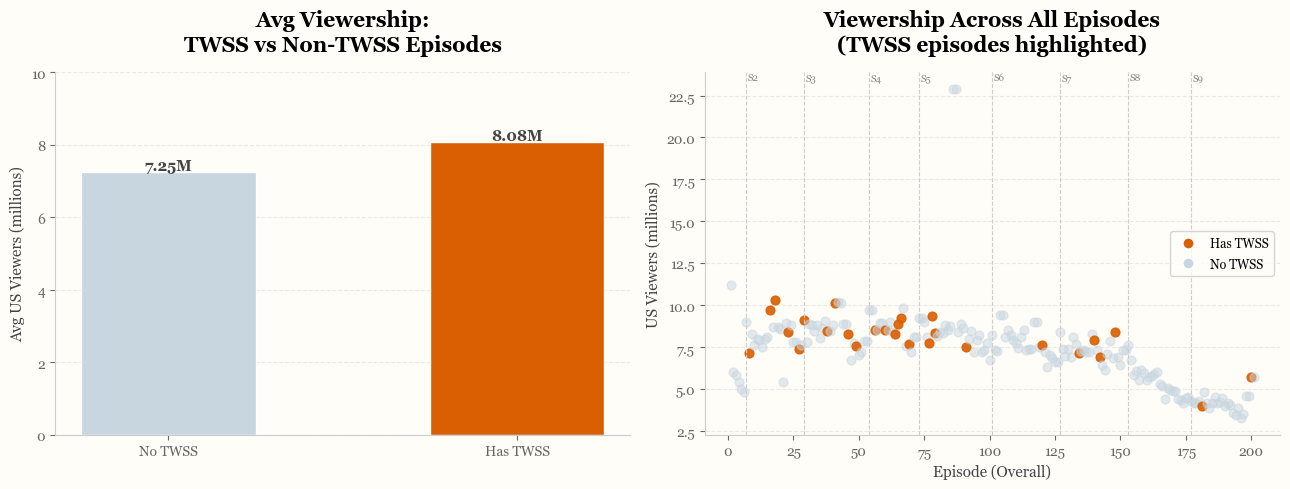

Chart 5 saved ✅


In [14]:
# Viewership comparison charts (Chart 5)
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=CREAM)
axes[0].set_facecolor(CREAM)
axes[1].set_facecolor(CREAM)

# Left: average viewership bar
colors_bar = [MUTED, ORANGE]
bars = axes[0].bar(viewership_comparison['has_twss'],
                   viewership_comparison['us_viewers'] / 1e6,
                   color=colors_bar, edgecolor='white', width=0.5)

for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{bar.get_height():.2f}M', ha='center', fontsize=11,
                fontweight='bold', color='#444444')

axes[0].set_ylabel("Avg US Viewers (millions)")
axes[0].set_title("Avg Viewership:\nTWSS vs Non-TWSS Episodes")
axes[0].set_ylim(0, 10)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.4, color='#CCCCCC')
axes[0].set_axisbelow(True)
sns.despine(ax=axes[0])

# Right: viewership scatter across all episodes
for _, row in episodes.iterrows():
    color = ORANGE if row['has_twss'] else MUTED
    alpha = 0.9 if row['has_twss'] else 0.5
    axes[1].scatter(row['episode_num_overall'], row['us_viewers'] / 1e6,
                    color=color, alpha=alpha, s=40)

# Season dividers
for season in range(2, 10):
    first_ep = episodes[episodes['season'] == season]['episode_num_overall'].min()
    axes[1].axvline(x=first_ep, color='#CCCCCC', linestyle='--', linewidth=0.8)
    axes[1].text(first_ep + 0.5, axes[1].get_ylim()[1] * 0.98, f'S{season}',
                fontsize=7, color='#888888')

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=ORANGE,
           markersize=8, label='Has TWSS'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=MUTED,
           markersize=8, label='No TWSS')
]
axes[1].legend(handles=legend_elements, fontsize=9)
axes[1].set_xlabel("Episode (Overall)")
axes[1].set_ylabel("US Viewers (millions)")
axes[1].set_title("Viewership Across All Episodes\n(TWSS episodes highlighted)")
axes[1].yaxis.grid(True, linestyle='--', alpha=0.4, color='#CCCCCC')
axes[1].set_axisbelow(True)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('charts/05_viewership.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved ✅")

## 4. Key Findings & Conclusions

### What the data tells us:

| **Finding** | Detail |

| **Total instances** | 34 confirmed TWSS across the whole series |

| **Peak season** | Season 4 with 10 instances |

| **Michael's share** | 23 out of 34 (68%) |

| **Season 1 & 8** | Zero instances — S1 predates the joke, S8 reflects Michael's absence |

| **Longest gap** | 33 episodes before Creed's callback in S9E5 |

| **Final line** | Michael's very last TWSS in the series is in Dwight and Angela's wedding episode (S9E24) |


### Limitations
- Dataset may not capture every instance depending on transcript accuracy
- Viewership correlation analysis is limited by confounding — TWSS frequency 
and viewership both decline together across seasons, making causal claims impossible

### Final thought
The trajectory of "That's what she said" is essentially a proxy for Michael Scott's 
presence and energy in the show. It rises with his confidence, peaks at his most 
charismatic, fades as the show matures, and disappears entirely when he leaves — 
only returning as a fond callback in the finale.